In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import torch
import numpy as np
from analysis.analyzer import ModelAnalyzer, load_model

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
p = 106
EQ_POS = 3

RUN = "ptg_wd0.5_bs512_ms1235_ds43_17007856"
model = load_model(PROJECT_ROOT / "outputs/runs-p106/pt-g" / RUN / "model.pt")
a = ModelAnalyzer(model, task="ptg", device=DEVICE, label="PT-G")

g++ (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
Copyright (C) 2021 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

Moving model to device:  cuda
Moving model to device:  cuda


In [3]:
# hook_z at the = position: (p*p, n_heads, d_head)
z_all = a.cache["blocks.0.attn.hook_z"][:, EQ_POS].permute([1, 0, 2])
z_np = z_all.cpu().numpy()
print(f"hook_z shape: {z_all.shape}")  # (11236, 4, 32)

for h in range(model.cfg.n_heads):
    print(f"  Head {h}: {z_all[h].shape}")

hook_z shape: torch.Size([4, 11236, 32])
  Head 0: torch.Size([11236, 32])
  Head 1: torch.Size([11236, 32])
  Head 2: torch.Size([11236, 32])
  Head 3: torch.Size([11236, 32])


In [5]:
from util import train_probe

for h in range(model.cfg.n_heads):
    clf, train_acc, test_acc = train_probe(z_np[h], a.parity_labels.astype(int))
    print(f"Test accuracy at head {h}: {test_acc:.2f}")

Test accuracy at head 0: 0.50
Test accuracy at head 1: 0.50
Test accuracy at head 2: 0.48
Test accuracy at head 3: 0.57


In [6]:
for h1 in range(model.cfg.n_heads):
    for h2 in range(h1, model.cfg.n_heads):
        clf, train_acc, test_acc = train_probe((z_np[h1] + z_np[h2]), a.parity_labels.astype(int))
        if test_acc > 0.9: print(f"Test accuracy at head {(h1, h2)}: {test_acc:.2f}")

Test accuracy at head (2, 3): 1.00


In [7]:
h1, h2 = 2,3
clf, train_acc, test_acc = train_probe((z_np[h1] + z_np[h2]), a.parity_labels.astype(int))

In [8]:
w, b = clf.coef_[0], clf.intercept_[0]

In [33]:
import matplotlib.pyplot as plt
%matplotlib inline

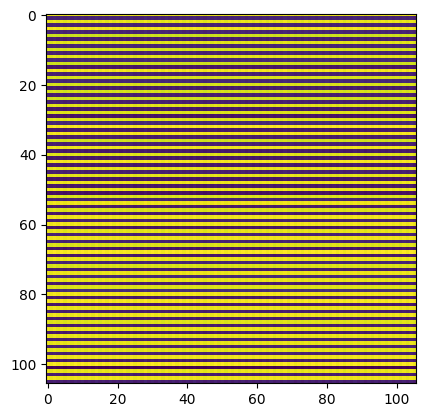

In [35]:
plt.imshow((z_np[h1] @ w).reshape(p,p))
plt.show()

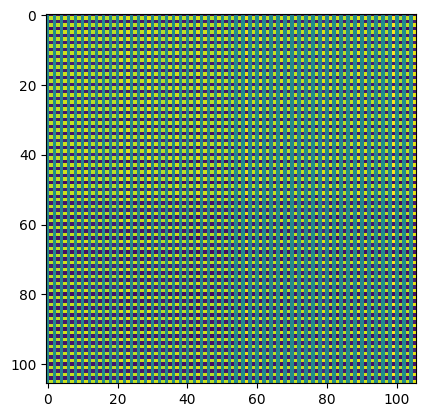

In [36]:
plt.imshow((z_np[h2] @ w).reshape(p,p))

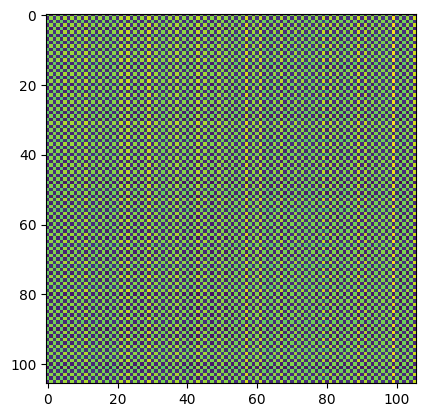

In [38]:
plt.imshow(((z_np[h2] + z_np[h1])@ w).reshape(p,p))

In [ ]:
(z_np[h1] @ w).reshape(p,p)

## Fourier Transform

In [49]:
from trainer.utils import fourier_transform_2d
import importlib
import util
importlib.reload(util)
from util import top_fourier_2d

score_h1 = (z_np[h1] @ w).reshape(p, p)
ft = fourier_transform_2d(score_h1, p=p)
ft

array([[-5.0530032e+02,  1.2678385e-01,  4.5073215e-02, ...,
         2.6452949e-02, -9.1567207e-03,  1.2114967e+01],
       [ 1.2549152e+00, -2.8962758e-04, -1.2595051e-05, ...,
        -1.2404059e-05,  1.4525596e-05, -3.3227194e-02],
       [-4.0567904e+00, -4.8598889e-04,  2.9560909e-04, ...,
         1.3040264e-04,  4.4035380e-05, -7.3122710e-02],
       ...,
       [-3.9719727e+00, -1.1968985e-04,  6.4079789e-04, ...,
         3.1882524e-04,  4.2047352e-05, -4.8867702e-02],
       [ 4.2639976e+00, -5.6268647e-04, -1.2365757e-03, ...,
        -6.3964352e-04, -1.2036413e-05,  4.3842793e-03],
       [ 6.3732483e+02, -4.1538239e-02, -9.7692668e-02, ...,
        -5.0189972e-02, -1.3622642e-03,  6.4788818e-01]], dtype=float32)

In [52]:
top_fourier_2d((z_np[h1] @ w).reshape(p, p), p, top_k = 4)

,Rank,Freq (a),Freq (b),Coefficient,|Coefficient|
0,1,cos 53,Const,637.324829,637.324829
1,2,Const,Const,-505.300323,505.300323
2,3,Const,cos 53,12.114967,12.114967
3,4,sin 51,Const,7.166740,7.166740


In [53]:
top_fourier_2d((z_np[h2] @ w).reshape(p, p), p, top_k = 4)

,Rank,Freq (a),Freq (b),Coefficient,|Coefficient|
0,1,cos 53,Const,-678.585938,678.585938
1,2,cos 53,cos 53,650.057251,650.057251
2,3,Const,Const,-355.809326,355.809326
3,4,Const,cos 53,-30.560970,30.560970


In [54]:
top_fourier_2d((z_np[h1] @ w + z_np[h2] @ w).reshape(p, p), p, top_k = 4)

,Rank,Freq (a),Freq (b),Coefficient,|Coefficient|
0,1,Const,Const,-861.109558,861.109558
1,2,cos 53,cos 53,650.705078,650.705078
2,3,cos 53,Const,-41.260952,41.260952
3,4,Const,cos 53,-18.445982,18.445982


## Decomposing into components

In [10]:
H = h2  # or h2

# QK part: attention weights from = to each source position
attn = a.cache["blocks.0.attn.hook_pattern"][:, H, EQ_POS, :].cpu().numpy()  # (p*p, 4)

# V part: value vectors per token per position
W_E = model.embed.W_E.detach().cpu()        # (vocab, d_model)
W_pos = model.pos_embed.W_pos.detach().cpu() # (n_ctx, d_model)
W_V = model.blocks[0].attn.W_V.detach().cpu()[H]  # (d_model, d_head)

tok = a.tokenizer
V_bos = ((W_E[tok.bos_token_id] + W_pos[0]) @ W_V).numpy()  # (d_head,) — constant
V_eq  = ((W_E[tok.eq_token_id]  + W_pos[3]) @ W_V).numpy()  # (d_head,) — constant
V_pos1 = ((W_E[:p] + W_pos[1]) @ W_V).numpy()  # (p, d_head) — indexed by a
V_pos2 = ((W_E[:p] + W_pos[2]) @ W_V).numpy()  # (p, d_head) — indexed by b

# Per-input (a,b) indices
a_tok = np.array([aa for aa in range(p) for _ in range(p)])
b_tok = np.array([bb for _ in range(p) for bb in range(p)])

# 4 terms: each (p*p, d_head)
term_bos = attn[:, 0:1] * V_bos          # broadcast
term_a   = attn[:, 1:2] * V_pos1[a_tok]
term_b   = attn[:, 2:3] * V_pos2[b_tok]
term_eq  = attn[:, 3:4] * V_eq

# Verify: should match z_np[H]
reconstructed = term_a + term_b 
print(f"Reconstruction error: {np.abs(reconstructed - z_np[H]).max():.6e}")

Reconstruction error: 8.849311e-02


In [15]:
H = h1
W_V = model.blocks[0].attn.W_V.detach().cpu()[H]  # (d_model, d_head)
V_pos1 = ((W_E[:p] + W_pos[1]) @ W_V).numpy()  # (p, d_head) — indexed by a
V_pos2 = ((W_E[:p] + W_pos[2]) @ W_V).numpy()  # (p, d_head) — indexed by b
np.round([(V_pos1@w)[::2].mean() , (V_pos1@w)[1::2].mean()], 2), np.round([(V_pos2@w)[::2].mean() , (V_pos2@w)[1::2].mean()], 2)

(array([  1.94, -10.46]), array([10.15, -2.25]))

In [16]:
H = h2
W_V = model.blocks[0].attn.W_V.detach().cpu()[H]  # (d_model, d_head)
V_pos1 = ((W_E[:p] + W_pos[1]) @ W_V).numpy()  # (p, d_head) — indexed by a
V_pos2 = ((W_E[:p] + W_pos[2]) @ W_V).numpy()  # (p, d_head) — indexed by b
np.round([(V_pos1@w)[::2].mean() , (V_pos1@w)[1::2].mean()], 2), np.round([(V_pos2@w)[::2].mean() , (V_pos2@w)[1::2].mean()], 2)

(array([-19.96,  -6.75]), array([-1.8 , 11.41]))

## Analyzing H1

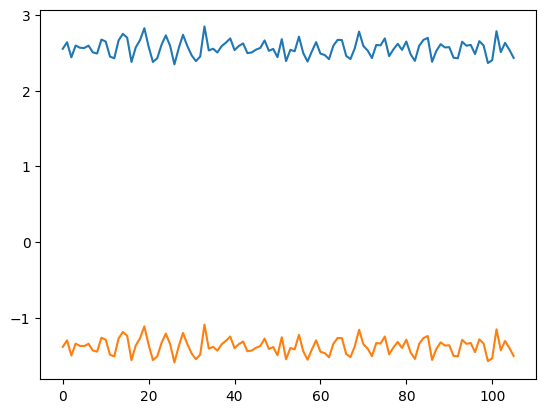

In [89]:
W_Q = model.blocks[0].attn.W_Q.detach().cpu()[h1]
W_K = model.blocks[0].attn.W_K.detach().cpu()[h1]
W_E = model.embed.W_E.detach().cpu()
W_pos = model.pos_embed.W_pos.detach().cpu()
d_head = W_Q.shape[1]

b_Q = model.blocks[0].attn.b_Q.detach().cpu()[h1]
b_K = model.blocks[0].attn.b_K.detach().cpu()[h1]

q_eq = (W_E[tok.eq_token_id] + W_pos[3]) @ W_Q + b_Q
k_pos1 = (W_E[:p] + W_pos[1]) @ W_K + b_K
k_pos2 = (W_E[:p] + W_pos[2]) @ W_K + b_K

scores_pos1 = (k_pos1 @ q_eq) / d_head**0.5
scores_pos2 = (k_pos2 @ q_eq) / d_head**0.5

assert torch.allclose(scores_pos1.float(), a.cache["blocks.0.attn.hook_attn_scores"][::p, h1, EQ_POS, 1].cpu(), atol=1e-4)
assert torch.allclose(scores_pos2.float(), a.cache["blocks.0.attn.hook_attn_scores"][:p, h1, EQ_POS, 2].cpu(), atol=1e-4)

plt.plot(scores_pos1)
plt.plot(scores_pos2)

### h1 attends to the first position always

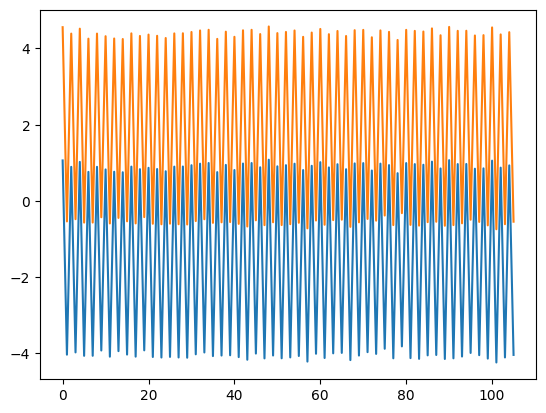

In [93]:
W_Q = model.blocks[0].attn.W_Q.detach().cpu()[h2]
W_K = model.blocks[0].attn.W_K.detach().cpu()[h2]
W_E = model.embed.W_E.detach().cpu()
W_pos = model.pos_embed.W_pos.detach().cpu()
d_head = W_Q.shape[1]

b_Q = model.blocks[0].attn.b_Q.detach().cpu()[h2]
b_K = model.blocks[0].attn.b_K.detach().cpu()[h2]

q_eq = (W_E[tok.eq_token_id] + W_pos[3]) @ W_Q + b_Q
k_pos1 = (W_E[:p] + W_pos[1]) @ W_K + b_K
k_pos2 = (W_E[:p] + W_pos[2]) @ W_K + b_K

scores_pos1 = (k_pos1 @ q_eq) / d_head**0.5
scores_pos2 = (k_pos2 @ q_eq) / d_head**0.5

assert torch.allclose(scores_pos1.float(), a.cache["blocks.0.attn.hook_attn_scores"][::p, h2, EQ_POS, 1].cpu(), atol=1e-4)
assert torch.allclose(scores_pos2.float(), a.cache["blocks.0.attn.hook_attn_scores"][:p, h2, EQ_POS, 2].cpu(), atol=1e-4)

plt.plot(scores_pos1)
plt.plot(scores_pos2)

### h2 


```
|          | pos2 odd | pos2 even |
|----------|----------|-----------|
| pos1 odd | 2        | 2         |
| pos1 even| 1 and 2  | 2         |
```